# Simulation of Precession Electron Diffraction (PED) Pattern #

Here, we simulate a precession electron diffraction (PED) pattern using the multislice method based on the crystal structure of gold (Au).

## 1. Creating a Crystal Structure ##

Create the crystal structure of gold using *lys_mat.CrystalStructure*.

In [9]:
from lys_mat import CrystalStructure
crys = CrystalStructure.loadFrom("data/Au.cif")
print(crys)

Symmetry: cubic Fm-3m (No. 225), Point group: m-3m
a = 4.07825, b = 4.07825, c = 4.07825, alpha = 90.00000, beta = 90.00000, gamma = 90.00000
--- atoms (4) ---
1: Au (Z = 79, Occupancy = 1) Pos = (0.00000, 0.00000, 0.00000)
2: Au (Z = 79, Occupancy = 1) Pos = (0.00000, 0.50000, 0.50000)
3: Au (Z = 79, Occupancy = 1) Pos = (0.50000, 0.00000, 0.50000)
4: Au (Z = 79, Occupancy = 1) Pos = (0.50000, 0.50000, 0.00000)


## 2. Defining the Computational Space ##

Define the simulation space using *FunctionSpace* class.

In [10]:
from lys_em import FunctionSpace
sp = FunctionSpace.fromCrystal(crys, 128, 128, 50)

## 3. Creating the Crystal Potential ##

Generate the potential field formed by the crystal using *CrystalPotential* class.

In [11]:
from lys_em import CrystalPotential
pot = CrystalPotential(sp, crys)

## 4. Defining the Electron Microscope Parameters ##

Set up the electron microscope parameters using *TEM* class. The tilt of the incident electron beam is defined using *TEMParameter* class and passed as a list to the optional argument params.

In [12]:
import numpy as np
from lys_em import TEM, TEMParameter
tem = TEM(60e3, params=[TEMParameter(tilt=[2, phi]) for phi in np.arange(0, 360, 360 / 90)])
# In TEMParameter.tilt, tilt[0] is the beam tilt angle from the optical axis (in degrees),
# and tilt[1] is the rotation angle within the plane perpendicular to the optical axis.

## 5. Running the Multislice Simulation ##

Run the multislice calculation using the setup from steps 1–4. The data are returned as a 3D array, where the 0th dimension corresponds to the precession rotation angle. By summing over this dimension, we obtain the simulated precession diffraction pattern.

In [13]:
from lys_em import multislice, diffraction
data = diffraction(multislice(pot, tem)).sum(axis=0)

We can visualize the diffraction pattern using matplotlib.

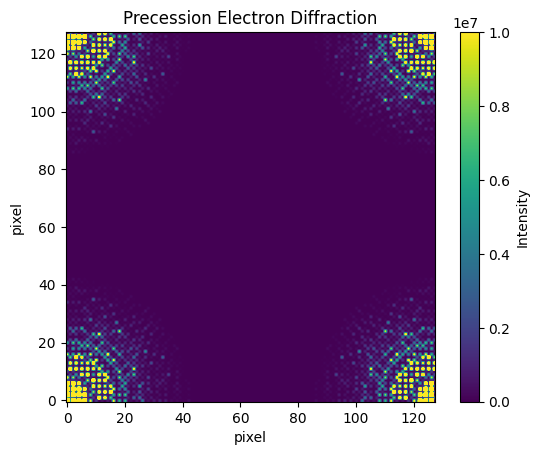

In [14]:
import matplotlib.pyplot as plt

plt.imshow(data.T, vmax=1e7, origin='lower')
plt.xlabel("pixel")
plt.ylabel("pixel")
plt.title("Precession Electron Diffraction")
plt.colorbar(label = "Intensity")
plt.show()

The wave vector for each pixel can be obtained using *kvec* property of *FunctionSpace* class.

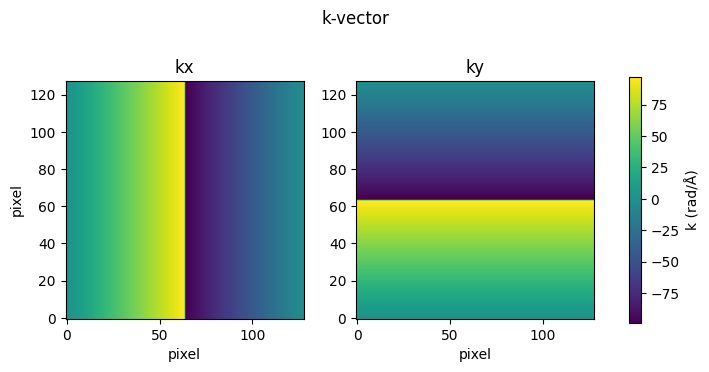

In [20]:
kx2D, ky2D = sp.kvec[:,:,0], sp.kvec[:,:,1]

fig, ax = plt.subplots(1,2,figsize=(7,5), constrained_layout=True)
im = []
for i, (v, name) in enumerate([(kx2D, 'kx'), (ky2D, 'ky')]):
    im.append(ax[i].imshow(v.T, vmin=min(np.min(kx2D), np.min(ky2D)), vmax=max(np.max(kx2D), np.max(ky2D)), origin='lower'))
    ax[i].set_title(name)
    ax[i].set_xlabel("pixel")
ax[0].set_ylabel("pixel")
fig.colorbar(im[-1], ax=ax, shrink=0.5, label="k (rad/Å)")
fig.suptitle('k-vector', y=0.88)
plt.show()

## 6. Optional: Rearranging the Data ##

As in the SAD simulation, rearranging the data improves the visual appearance, making it similar to experimentally obtained diffraction patterns.

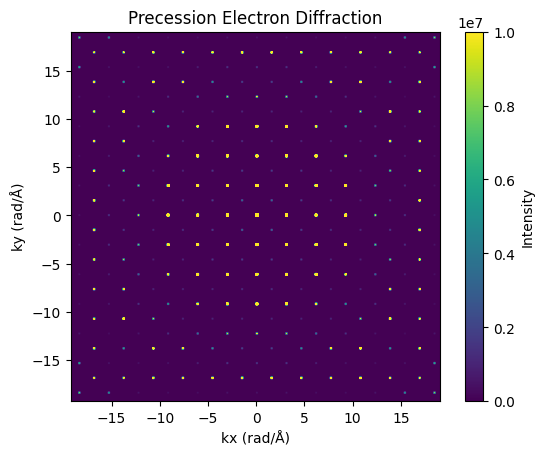

In [21]:
def makeInterval(data, kx, ky, kmax, size):
    d = np.array((kx[1]-kx[0], ky[1]-ky[0]))
    step = size // 2 // np.round(kmax//d).astype(int)
    n = size // 2 // step
    start, end = np.array(data.shape)//2-n, np.array(data.shape)//2+n+1 - np.isclose(size/2 - step*n,0).astype(int)

    res = np.zeros((size, size))    
    res[(size//2)%step[0]::step[0], (size//2)%step[1]::step[1]] = data[start[0]:end[0], start[1]:end[1]]
    k_new = np.linspace(-(size//2)*d/step, size//2*d/step, size, endpoint = size%2).T
    return res, k_new

data_sorted = np.roll(np.roll(data, data.shape[0]//2, axis=0), data.shape[1]//2, axis=1)
kx, ky = sp.kvec[:,0,0], sp.kvec[0,:,1]
data_arranged, k_new = makeInterval(data_sorted, kx, ky, 20, 200)

plt.imshow(data_arranged.T, vmax=1e7, extent=[k_new[0,0], k_new[0,-1], k_new[1,0], k_new[1,-1]], origin='lower')
plt.xlabel('kx (rad/Å)')
plt.ylabel('ky (rad/Å)')
plt.title("Precession Electron Diffraction")
plt.colorbar(label = "Intensity")
plt.show()

## Summary ##

Below is the complete code up to the execution of the multislice simulation.

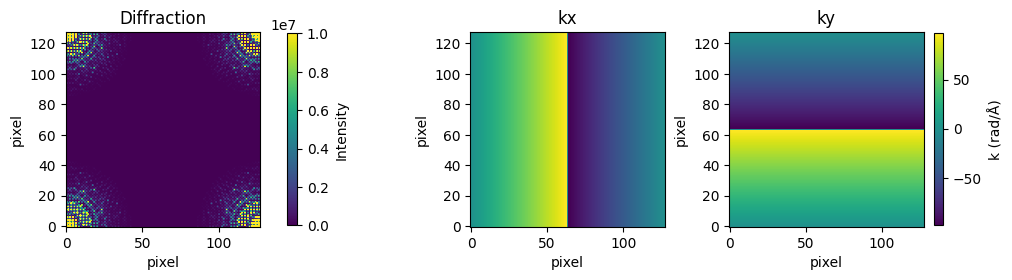

In [27]:
# Calculation

import numpy as np
from lys_mat import CrystalStructure
from lys_em import FunctionSpace, CrystalPotential, TEM, TEMParameter, multislice, diffraction

crys = CrystalStructure.loadFrom("data/Au.cif")
sp = FunctionSpace.fromCrystal(crys, 128, 128, 50)
pot = CrystalPotential(sp, crys)
tem = TEM(60e3, params=[TEMParameter(tilt=[2, phi]) for phi in np.arange(0, 360, 360 / 90)])
data = diffraction(multislice(pot, tem)).sum(axis=0)
kx2D, ky2D = sp.kvec[:, :, 0], sp.kvec[:, :, 1]


# Visualization of the result

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10,3), constrained_layout=True)
gs = GridSpec(1, 4, figure=fig, width_ratios=[1, 0.3, 1, 1])
ax = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[0,2]), fig.add_subplot(gs[0,3])]
dlist = [(data, "Diffraction"), (kx2D, "kx"), (ky2D, "ky")]
im = []
for i, (d, name) in enumerate(dlist):
    if i==0:
        im.append(ax[i].imshow(d.T, vmax=1e7, origin="lower"))
    else:
        im.append(ax[i].imshow(d.T, vmin=min(np.min(kx2D), np.min(ky2D)), vmax=max(np.max(kx2D), np.max(ky2D)), origin='lower'))
    ax[i].set_title(name)
    ax[i].set_xlabel('pixel')
    ax[i].set_ylabel('pixel')

fig.colorbar(im[0], ax=ax[0], shrink=0.7, label="Intensity")
fig.colorbar(im[2], ax=ax[2], shrink=0.7, label="k (rad/Å)")
plt.show()